# Best overall models + Ensemble

## Import

In [12]:
import time
import sys

import numpy as np
import pandas as pd

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

from sklearn.ensemble import HistGradientBoostingClassifier

import xgboost
from xgboost import XGBClassifier

import catboost
from catboost import CatBoostClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

from itertools import combinations
import copy

In [13]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Version control

In [14]:
print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("catboost:", catboost.__version__)
print("matplotlib:", mpl.__version__)
print("seaborn:", sns.__version__)

Python: 3.12.13
numpy: 1.26.4
pandas: 3.0.3
scikit-learn: 1.9.0
xgboost: 3.2.0
catboost: 1.2.10
matplotlib: 3.11.0
seaborn: 0.13.2


In [15]:
version_check = {
    "Python": ("3.12.13", sys.version.split()[0]),
    "numpy": ("1.26.4", np.__version__),
    "pandas": ("3.0.3", pd.__version__),
    "scikit-learn": ("1.9.0", sklearn.__version__),
    "xgboost": ("3.2.0", xgboost.__version__),
    "catboost": ("1.2.10", catboost.__version__),
    "matplotlib": ("3.11.0", mpl.__version__),
    "seaborn": ("0.13.2", sns.__version__)
}

df_versions = pd.DataFrame(version_check, index=["target", "actual"]).T
df_versions["match"] = df_versions["target"] == df_versions["actual"]

df_versions

,target,actual,match
Python,3.12.13,3.12.13,True
numpy,1.26.4,1.26.4,True
pandas,3.0.3,3.0.3,True
scikit-learn,1.9.0,1.9.0,True
xgboost,3.2.0,3.2.0,True
catboost,1.2.10,1.2.10,True
matplotlib,3.11.0,3.11.0,True
seaborn,0.13.2,0.13.2,True


## Dataframe

In [16]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [17]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../data/processed/train_idx.npy")
idx_val = np.load("../../data/processed/val_idx.npy")
idx_test = np.load("../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Variables

In [18]:
results = []
train_times = {}
modelle = {}

In [19]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

## Functions

In [20]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, x_test, y_test, train_time, best_iter=None):
    """AUC for Train, Val and Test Splits"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "auc_test": auc_test,
        "gini_val": 2 * auc_val - 1,
        "gini_test": 2 * auc_test - 1,
        "delta_auc_train_val": auc_train - auc_val,
        "delta_auc_train_test": auc_train - auc_test,
        "delta_auc_val_test": auc_val - auc_test,
        "best_iter": best_iter,
        "train_times": train_time
    }

In [21]:
def mv_for_cb(df, fill_var="missing"):
    """missing category for catboost"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

## Models

### HistGradientBoostingClassifier

In [22]:
name = "hgb_opt"

hgb_opt = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            (
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ), cat_cols
            ),
            ("passthrough", num_cols_no_calc + bin_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas")
    )),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        loss="log_loss",
        class_weight=None,
        categorical_features=None,
        scoring="loss",
        max_iter=5000,
        early_stopping=True,
        max_leaf_nodes=None,
        learning_rate=0.024687148414834312,
        min_samples_leaf=165,
        l2_regularization=0.004711123505991509,
        max_features=0.2469806711366302,
        max_bins=144,
        interaction_cst=None,
        validation_fraction=0.014823091721617599,
        n_iter_no_change=34,
        tol=8.37065478390795e-08,
        max_depth=6
    ))
])

In [23]:
start = time.time()
hgb_opt.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = hgb_opt

results.append(
    eval_modell(name, hgb_opt, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=hgb_opt["clf"].n_iter_)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


### XGBoostClassifier

In [24]:
name = "xgb_opt"

xgb_opt = Pipeline([
    ("prep", make_column_transformer(
        ("passthrough", feat_cols_no_calc),
        remainder="drop",
        verbose_feature_names_out=False
    ).set_output(transform="pandas")),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        device="cpu",
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        n_estimators=3000,
        early_stopping_rounds=100,
        learning_rate=0.07790268189585514,
        max_depth=7,
        min_child_weight=126.48831841040663,
        gamma=0.49311029649427224,
        reg_lambda=2.2458304124422743,
        reg_alpha=0.055327262047932445,
        max_delta_step=7,
        subsample=0.800054663467233,
        colsample_bynode=0.8968596357800713,
        scale_pos_weight=1,
        max_cat_to_onehot=105
    ))
])

In [25]:
x_val_xgb = xgb_opt["prep"].fit_transform(x_val)

In [26]:
start = time.time()
xgb_opt.fit(x_train, y_train, clf__eval_set=[(x_val_xgb, y_val)])
train_times[name] = time.time() - start

modelle[name] = xgb_opt

results.append(
    eval_modell(name, xgb_opt, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=xgb_opt["clf"].best_iteration)
)

[0]	validation_0-auc:0.60092
[1]	validation_0-auc:0.60441
[2]	validation_0-auc:0.60771
[3]	validation_0-auc:0.61099
[4]	validation_0-auc:0.61163
[5]	validation_0-auc:0.61371
[6]	validation_0-auc:0.61658
[7]	validation_0-auc:0.61757
[8]	validation_0-auc:0.61919
[9]	validation_0-auc:0.62000
[10]	validation_0-auc:0.62109
[11]	validation_0-auc:0.62191
[12]	validation_0-auc:0.62276
[13]	validation_0-auc:0.62309
[14]	validation_0-auc:0.62423
[15]	validation_0-auc:0.62480
[16]	validation_0-auc:0.62536
[17]	validation_0-auc:0.62619
[18]	validation_0-auc:0.62676
[19]	validation_0-auc:0.62711
[20]	validation_0-auc:0.62727
[21]	validation_0-auc:0.62793
[22]	validation_0-auc:0.62767
[23]	validation_0-auc:0.62798
[24]	validation_0-auc:0.62853
[25]	validation_0-auc:0.62895
[26]	validation_0-auc:0.62942
[27]	validation_0-auc:0.63002
[28]	validation_0-auc:0.63027
[29]	validation_0-auc:0.63071
[30]	validation_0-auc:0.63079
[31]	validation_0-auc:0.63106
[32]	validation_0-auc:0.63158
[33]	validation_0-au

### CatBoostClassifier

#### CatBoostClassifier (Plain, 75%)

In [27]:
name = "cb_opt_1"

cb_opt_1 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.17595817710624895,
        depth=4,
        l2_leaf_reg=3.9143184149527266,
        random_strength=0.5015455446392323,
        one_hot_max_size=10,
        leaf_estimation_iterations=2,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.7854715288197278
    ))
])

In [28]:
x_val_cb = cb_opt_1["prep"].fit_transform(x_val)

In [29]:
start = time.time()
cb_opt_1.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = cb_opt_1

results.append(
    eval_modell(name, cb_opt_1, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=cb_opt_1["clf"].get_best_iteration())
)

### CatBoostClassifier (Plain, 100%)

In [30]:
name = "cb_opt_2"

cb_opt_2 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.05445057683691509,
        depth=8,
        l2_leaf_reg=7.076480471311773,
        random_strength=0.8387744815011882,
        one_hot_max_size=18,
        leaf_estimation_iterations=5,
        auto_class_weights=None,
        bootstrap_type="Bayesian",
        bagging_temperature=1.8158099900059381
    ))
])

In [31]:
x_val_cb = cb_opt_2["prep"].fit_transform(x_val)

In [32]:
start = time.time()
cb_opt_2.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = cb_opt_2

results.append(
    eval_modell(name, cb_opt_2, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=cb_opt_2["clf"].get_best_iteration())
)

### CatBoostClassifier (Ordered, 100%)

In [33]:
name = "cb_opt_3"

cb_opt_3 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Ordered",
        learning_rate=0.10624277494598432,
        depth=7,
        l2_leaf_reg=18.039747295507677,
        random_strength=0.005187373722068937,
        one_hot_max_size=105,
        leaf_estimation_iterations=1,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.8119454704358904
    ))
])

In [34]:
x_val_cb = cb_opt_3["prep"].fit_transform(x_val)

In [35]:
start = time.time()
cb_opt_3.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = cb_opt_3

results.append(
    eval_modell(name, cb_opt_3, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=cb_opt_3["clf"].get_best_iteration())
)

### Logistic Regression

In [36]:
name = "lr_opt"

lr_opt = Pipeline([
    ("prep", make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ), num_cols_no_calc
        ),
        (
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first"
            ), low_kard_cols
        ),
        (
            make_pipeline(
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ),
                StandardScaler()
            ), high_kard_cols
        ),
        ("passthrough", bin_cols_no_calc),
        remainder="drop"
    )),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
        tol=1e-4,
        fit_intercept=True,
        penalty="elasticnet",
        solver="saga",
        C=0.029135585913319124,
        l1_ratio=0.8,
        class_weight="balanced"
    ))
])

In [37]:
start = time.time()
lr_opt.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = lr_opt

results.append(
    eval_modell(name, lr_opt, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=lr_opt["clf"].n_iter_[0])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

## Evaluation

In [38]:
df_results = pd.DataFrame(results).sort_values("auc_test", ascending=False)
df_results

,model_idx,auc_train,auc_val,auc_test,gini_val,gini_test,delta_auc_train_val,delta_auc_train_test,delta_auc_val_test,best_iter,train_times
1,xgb_opt,0.680683,0.639986,0.649495,0.279972,0.298989,0.040697,0.031189,-0.009508,139,15.060510
4,cb_opt_3,0.685571,0.635504,0.647561,0.271008,0.295121,0.050067,0.038010,-0.012057,789,135.875244
0,hgb_opt,0.683650,0.634533,0.647474,0.269067,0.294947,0.049116,0.036176,-0.012940,365,14.935154
3,cb_opt_2,0.692775,0.636402,0.647385,0.272804,0.294769,0.056373,0.045390,-0.010983,558,105.866072
2,cb_opt_1,0.664717,0.633687,0.647273,0.267374,0.294546,0.031030,0.017444,-0.013586,518,58.816717
5,lr_opt,0.635121,0.618241,0.637237,0.236481,0.274475,0.016880,-0.002117,-0.018997,500,307.672829


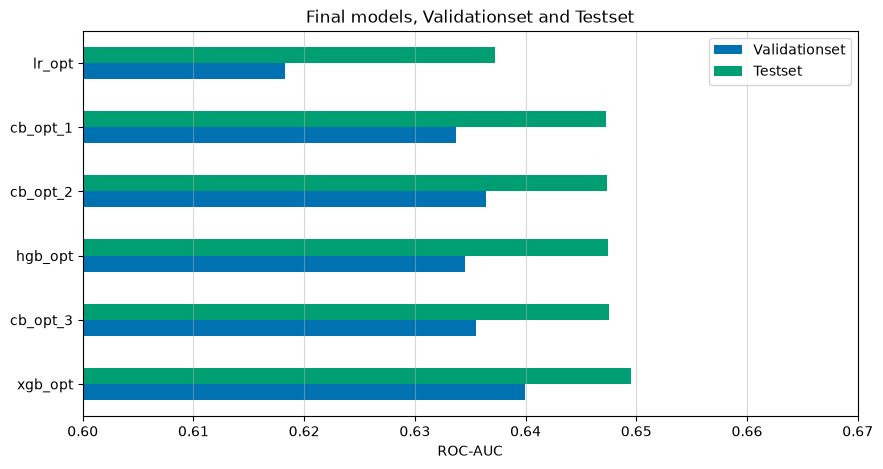

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["auc_val", "auc_test"]]
    .rename(columns={
        "auc_val": "Validationset",
        "auc_test": "Testset"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlim(0.60, 0.67)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
ax.set_title("Final models, Validationset and Testset")
ax.legend()
ax.grid(axis="x", alpha=0.5)

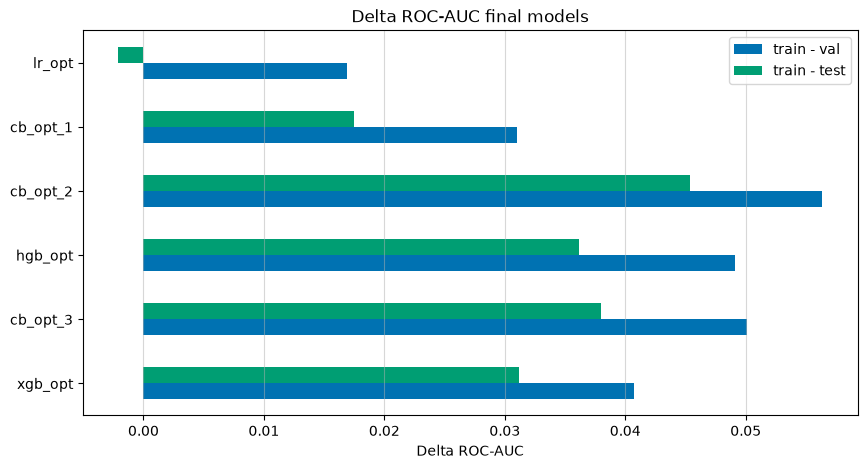

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["delta_auc_train_val", "delta_auc_train_test"]]
    .rename(columns={
        "delta_auc_train_val": "train - val",
        "delta_auc_train_test": "train - test"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlabel("Delta ROC-AUC")
ax.set_ylabel("")
ax.set_title("Delta ROC-AUC final models")
ax.legend()
ax.grid(axis="x", alpha=0.5)

## Result Validation via member values (L_L NB23)

In [41]:
referenz = {
    "xgb_opt": {"auc_test": 0.649495, "best_iter": 139},
    "hgb_opt": {"auc_test": 0.647474, "best_iter": 365},
    "cb_opt_1": {"auc_test": 0.647273, "best_iter": 518},
    "cb_opt_2": {"auc_test": 0.647385, "best_iter": 558},
    "cb_opt_3": {"auc_test": 0.647561, "best_iter": 789},
    "lr_opt": {"auc_test": 0.637237, "best_iter": 500}
}

In [42]:
check = []

for name, ref in referenz.items():
    row = df_results.loc[df_results["model_idx"] == name].iloc[0]
    check.append({
         "model_idx": name,
        "auc_test_23": ref["auc_test"],
        "auc_test_new": row["auc_test"],
        "diff_auc": row["auc_test"] - ref["auc_test"],
        "best_iter_23": ref["best_iter"],
        "best_iter_new": row["best_iter"],
        "identical": abs(row["auc_test"] - ref["auc_test"]) < 1e-4 and row["best_iter"] == ref["best_iter"]
    })

pd.DataFrame(check)

,model_idx,auc_test_23,auc_test_new,diff_auc,best_iter_23,best_iter_new,identical
0,xgb_opt,0.649495,0.649495,-4.720969e-07,139,139,True
1,hgb_opt,0.647474,0.647474,-4.585453e-07,365,365,True
2,cb_opt_1,0.647273,0.647273,1.855940e-07,518,518,True
3,cb_opt_2,0.647385,0.647385,-4.064509e-07,558,558,True
4,cb_opt_3,0.647561,0.647561,-2.630702e-07,789,789,True
5,lr_opt,0.637237,0.637237,4.502403e-07,500,500,True


## Predictions

In [43]:
Pred_xgb_opt = xgb_opt.predict_proba(x_test)[:, 1]
Pred_hgb_opt = hgb_opt.predict_proba(x_test)[:, 1]
Pred_cb_opt_1 = cb_opt_1.predict_proba(x_test)[:, 1]
Pred_cb_opt_2 = cb_opt_2.predict_proba(x_test)[:, 1]
Pred_cb_opt_3 = cb_opt_3.predict_proba(x_test)[:, 1]
Pred_lr_opt = lr_opt.predict_proba(x_test)[:, 1]

preds_test = pd.DataFrame({
    "Pred_xgb_opt": xgb_opt.predict_proba(x_test)[:, 1],
    "Pred_hgb_opt": hgb_opt.predict_proba(x_test)[:, 1],
    "Pred_cb_opt_1": cb_opt_1.predict_proba(x_test)[:, 1],
    "Pred_cb_opt_2": cb_opt_2.predict_proba(x_test)[:, 1],
    "Pred_cb_opt_3": cb_opt_3.predict_proba(x_test)[:, 1],
    "Pred_lr_opt": lr_opt.predict_proba(x_test)[:, 1]
}, index=x_test.index)

## Prediction correlation

In [44]:
pred_korr = preds_test.corr(method="spearman").round(3)
pred_korr

,Pred_xgb_opt,Pred_hgb_opt,Pred_cb_opt_1,Pred_cb_opt_2,Pred_cb_opt_3,Pred_lr_opt
Pred_xgb_opt,1.000,0.958,0.945,0.951,0.943,0.877
Pred_hgb_opt,0.958,1.000,0.952,0.958,0.948,0.898
Pred_cb_opt_1,0.945,0.952,1.000,0.965,0.958,0.897
Pred_cb_opt_2,0.951,0.958,0.965,1.000,0.956,0.911
Pred_cb_opt_3,0.943,0.948,0.958,0.956,1.000,0.884
Pred_lr_opt,0.877,0.898,0.897,0.911,0.884,1.000


Text(0.5, 1.0, 'Correlation of predictions (testset)')

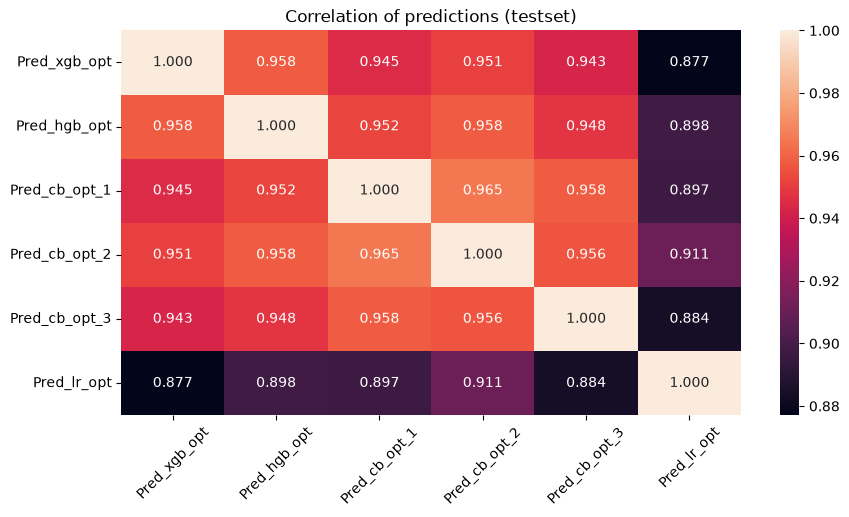

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    pred_korr,
    ax=ax,
    annot=True,
    fmt=".3f"
)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Correlation of predictions (testset)")

## Ensemble-method-experiments

In [46]:
preds_val = pd.DataFrame({
    "Pred_xgb_opt": xgb_opt.predict_proba(x_val)[:, 1],
    "Pred_hgb_opt": hgb_opt.predict_proba(x_val)[:, 1],
    "Pred_cb_opt_1": cb_opt_1.predict_proba(x_val)[:, 1],
    "Pred_cb_opt_2": cb_opt_2.predict_proba(x_val)[:, 1],
    "Pred_cb_opt_3": cb_opt_3.predict_proba(x_val)[:, 1],
    "Pred_lr_opt": lr_opt.predict_proba(x_val)[:, 1]
}, index=x_val.index)

### Experiment 1: Testing Ensemble Voting Approaches

Compared are a) simple averaging of predictions (soft voting), b) rank averaging, where individual models predictions are sorted from low to high and then averaged based on their relative rank, and c) weighted rank averaging, which incorporates an assessment of predictive strength via vote weighting based on individual model quality.

In [47]:
ranks_val = preds_val.rank(pct=True)
ranks_test = preds_test.rank(pct=True)

In [48]:
ensemble_results = []

model_auc = {
    model: roc_auc_score(y_val, preds_val[model])
    for model in preds_val.columns
}

for k in range(2, len(preds_val.columns) + 1):

    for modelle_k in combinations(preds_val.columns, k):

        modelle_k = list(modelle_k)

        pred_val = preds_val[modelle_k].mean(axis=1)
        pred_test = preds_test[modelle_k].mean(axis=1)

        ensemble_results.append({
            "k": k,
            "method": "averaging",
            "models": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })

        pred_val = ranks_val[modelle_k].mean(axis=1)
        pred_test = ranks_test[modelle_k].mean(axis=1)

        ensemble_results.append({
            "k": k,
            "method": "rank",
            "models": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })

        gewichte = np.array([
            model_auc[model] - 0.5
            for model in modelle_k
        ])

        gewichte = gewichte / gewichte.sum()

        pred_val = (
            ranks_val[modelle_k] * gewichte
        ).sum(axis=1)

        pred_test = (
            ranks_test[modelle_k] * gewichte
        ).sum(axis=1)

        ensemble_results.append({
            "k": k,
            "method": "weighted rank",
            "models": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })

In [49]:
df_ensemble = pd.DataFrame(ensemble_results)

df_ensemble.sort_values(
    "auc_val",
    ascending=False
).head(10)

,k,method,models,auc_val,auc_test
8,2,weighted rank,Pred_xgb_opt + Pred_cb_opt_2,0.639711,0.649993
7,2,rank,Pred_xgb_opt + Pred_cb_opt_2,0.639690,0.649980
6,2,averaging,Pred_xgb_opt + Pred_cb_opt_2,0.639550,0.649968
11,2,weighted rank,Pred_xgb_opt + Pred_cb_opt_3,0.639513,0.650384
10,2,rank,Pred_xgb_opt + Pred_cb_opt_3,0.639479,0.650373
68,3,weighted rank,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639382,0.650323
67,3,rank,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639353,0.650307
9,2,averaging,Pred_xgb_opt + Pred_cb_opt_3,0.639274,0.650179
66,3,averaging,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639191,0.650251
116,4,weighted rank,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_2 + ...,0.638808,0.650308


In [50]:
best_pro_k = (
    df_ensemble
    .sort_values("auc_val", ascending=False)
    .groupby(["method", "k"])
    .head(1)
    .sort_values(["method", "k"])
)

best_pro_k[
    [
        "k",
        "method",
        "models",
        "auc_val",
        "auc_test"
    ]
]

,k,method,models,auc_val,auc_test
6,2,averaging,Pred_xgb_opt + Pred_cb_opt_2,0.639550,0.649968
66,3,averaging,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639191,0.650251
114,4,averaging,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_2 + ...,0.638656,0.650260
150,5,averaging,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.638187,0.650164
168,6,averaging,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.629604,0.645572
7,2,rank,Pred_xgb_opt + Pred_cb_opt_2,0.639690,0.649980
67,3,rank,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639353,0.650307
115,4,rank,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_2 + ...,0.638776,0.650300
151,5,rank,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.638289,0.650223
169,6,rank,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.636428,0.649661


In [51]:
kurz = {
    "Pred_xgb_opt": "XGB",
    "Pred_hgb_opt": "HGB",
    "Pred_cb_opt_1": "Cat1",
    "Pred_cb_opt_2": "Cat2",
    "Pred_cb_opt_3": "Cat3",
    "Pred_lr_opt": "LogReg"
}

best_pro_k = best_pro_k.copy()

best_pro_k["models_short"] = best_pro_k["models"]

best_pro_k["models_short"] = best_pro_k["models"].apply(
    lambda x: " + ".join(
        kurz.get(modell, modell)
        for modell in x.split(" + ")
    )
)

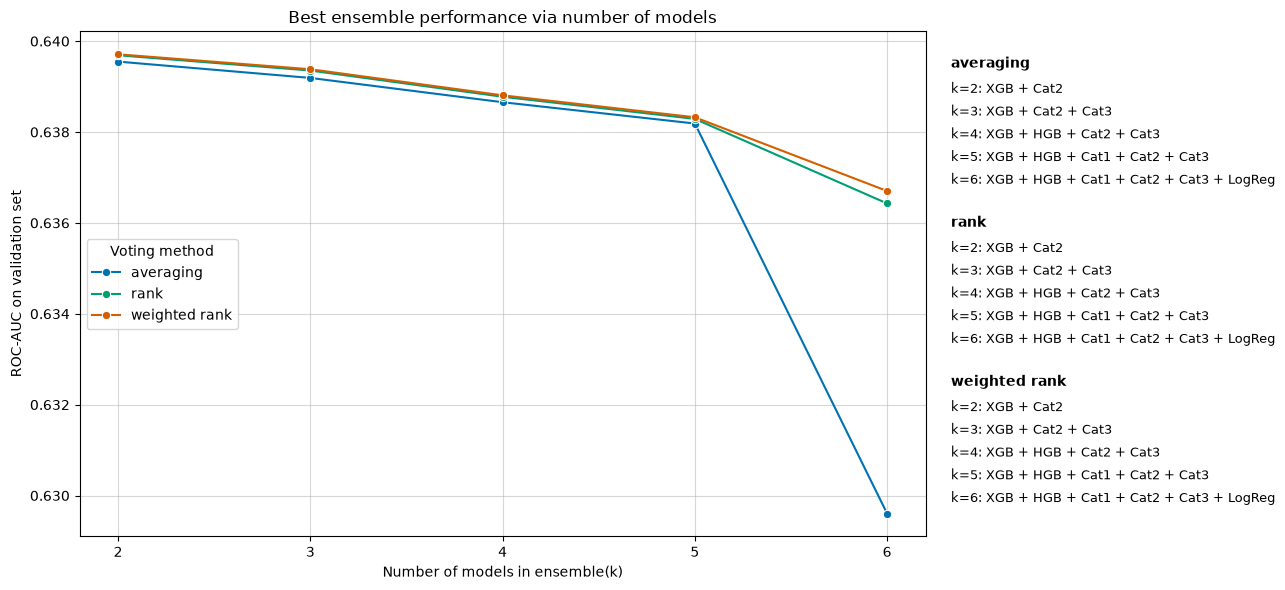

In [52]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=best_pro_k,
    x="k",
    y="auc_val",
    hue="method",
    marker="o",
    ax=ax
)

ax.set_xlabel("Number of models in ensemble(k)")
ax.set_ylabel("ROC-AUC on validation set")
ax.set_title("Best ensemble performance via number of models")

ax.set_xticks(range(2, 7))

ax.legend(
    title="Voting method",
    loc="center left"
)

ax.grid(alpha=0.5)


text_y = 0.95

for verfahren in best_pro_k["method"].unique():

    ax.text(
        1.03,
        text_y,
        verfahren,
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

    text_y -= 0.05

    temp = (
        best_pro_k[
            best_pro_k["method"] == verfahren
        ]
        .sort_values("k")
    )

    for _, row in temp.iterrows():

        ax.text(
            1.03,
            text_y,
            f'k={row["k"]}: {row["models_short"]}',
            transform=ax.transAxes,
            va="top",
            fontsize=9
        )

        text_y -= 0.045

    text_y -= 0.04

plt
plt.tight_layout()
plt.show()

### Experiment 2: Testing Model Selection Approaches

There are several ways to decide how (additional) individual models are added to an ensemble. Three approaches are compared here: a) random addition of a further model without any additional heuristic, b) greedy selection, a mechanism where the best individual model is chosen first and then, step by step, the model that yields the highest performance gain is added, and c) top performance selection, where all combinations are tested against each other to independently find the best composition for each ensemble size k.

In [53]:
def ensemble_pred(modelle, ranks):

    gewichte = np.array([
        model_auc[m] - 0.5
        for m in modelle
    ])

    gewichte = gewichte / gewichte.sum()

    return (ranks[modelle] * gewichte).sum(axis=1)

In [54]:
pred_val = ensemble_pred(
    modelle_k,
    ranks_val
)

In [55]:

absolute = (
    df_ensemble[
        df_ensemble["method"] == "weighted rank"
    ]
    .sort_values("auc_val", ascending=False)
    .groupby("k")
    .head(1)
    .sort_values("k")
    .copy()
)

absolute["selection"] = "Absolute Performance"

In [56]:
bestes_einzelmodell = max(
    model_auc,
    key=model_auc.get
)

rng = np.random.default_rng(RANDOM_STATE)

rest = [
    m for m in preds_val.columns
    if m != bestes_einzelmodell
]

reihenfolge = [
    bestes_einzelmodell,
    *rng.permutation(rest)
]

In [57]:
random_results = []

for k in range(2, 7):

    modelle_k = list(reihenfolge[:k])

    pred_val = ensemble_pred(
        modelle_k,
        ranks_val
    )

    pred_test = ensemble_pred(
        modelle_k,
        ranks_test
    )

    random_results.append({
        "k": k,
        "selection": "random",
        "models": " + ".join(modelle_k),
        "auc_val": roc_auc_score(y_val, pred_val),
        "auc_test": roc_auc_score(y_test, pred_test)
    })

random_results = pd.DataFrame(random_results)

In [58]:
greedy_results = []

ausgewaehlt = [bestes_einzelmodell]

for k in range(2, 7):

    best_auc = 0
    best_model = None

    for model in preds_val.columns:

        if model in ausgewaehlt:
            continue

        kandidaten = ausgewaehlt + [model]

        pred_val = ensemble_pred(
            kandidaten,
            ranks_val
        )

        auc = roc_auc_score(
            y_val,
            pred_val
        )

        if auc > best_auc:
            best_auc = auc
            best_model = model

    ausgewaehlt.append(best_model)

    pred_test = ensemble_pred(
        ausgewaehlt,
        ranks_test
    )

    greedy_results.append({
        "k": k,
        "selection": "Greedy",
        "models": " + ".join(ausgewaehlt),
        "auc_val": best_auc,
        "auc_test": roc_auc_score(y_test, pred_test)
    })

greedy_results = pd.DataFrame(greedy_results)

In [59]:
absolute_simple = absolute[
    ["k", "selection", "models", "auc_val", "auc_test"]
]

df_auswahl = pd.concat([
    absolute_simple,
    random_results,
    greedy_results
])

df_auswahl = df_auswahl.sort_values([
    "selection",
    "k"
])

df_auswahl

,k,selection,models,auc_val,auc_test
8,2,Absolute Performance,Pred_xgb_opt + Pred_cb_opt_2,0.639711,0.649993
68,3,Absolute Performance,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639382,0.650323
116,4,Absolute Performance,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_2 + ...,0.638808,0.650308
152,5,Absolute Performance,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.638324,0.650236
170,6,Absolute Performance,Pred_xgb_opt + Pred_hgb_opt + Pred_cb_opt_1 + ...,0.636702,0.649776
0,2,Greedy,Pred_xgb_opt + Pred_cb_opt_2,0.639711,0.649993
1,3,Greedy,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3,0.639382,0.650323
2,4,Greedy,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3 +...,0.638808,0.650308
3,5,Greedy,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3 +...,0.638324,0.650236
4,6,Greedy,Pred_xgb_opt + Pred_cb_opt_2 + Pred_cb_opt_3 +...,0.636702,0.649776


In [60]:
df_auswahl["models_short"] = df_auswahl["models"].apply(
    lambda x: " + ".join(
        kurz.get(modell, modell)
        for modell in x.split(" + ")
    )
)

In [61]:
best_verfahren = df_auswahl.sort_values("auc_val", ascending=False).iloc[0]["selection"]

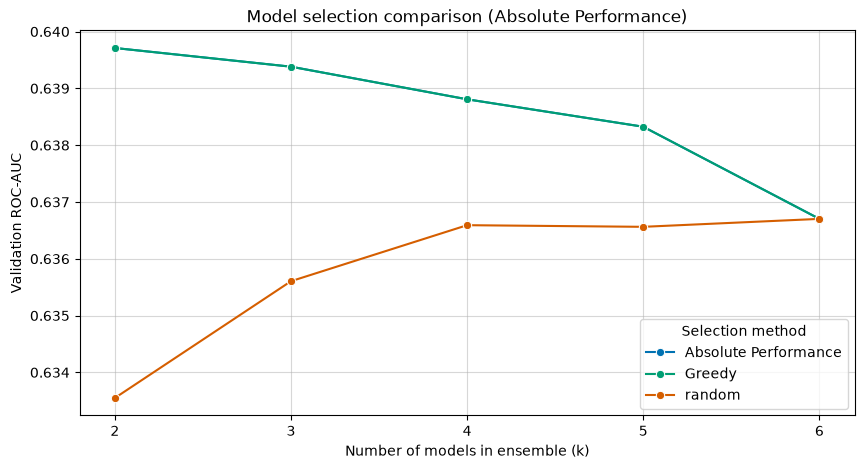

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_auswahl,
    x="k",
    y="auc_val",
    hue="selection",
    marker="o",
    ax=ax
)

ax.set_xlabel("Number of models in ensemble (k)")
ax.set_ylabel("Validation ROC-AUC")

ax.set_title(
    f"Model selection comparison ({best_verfahren})"
)

ax.set_xticks(range(2, 7))

ax.legend(
    title="Selection method"
)

ax.grid(alpha=0.5)

plt.show()

### Experiment 3: Seed Ensembles Based on the Strongest Individual Models

To test whether the performance gain from ensemble formation arises only from the different model types, or whether the robustness of strong individual models performance can itself be increased through variation such as seeding, the next step examines this by training and combining the strongest individual models (CatBoost, XGBoost, HistGradientBoosting, and logistic regression) across different seeds.

In [63]:
seeds = [42, 123, 456, 789, 2026, 12, 56, 214, 90, 30, 1709, 851, 970, 1205, 16]

best_modelle = {
    "XGBoost": xgb_opt,
    "HGB": hgb_opt,
    "CatBoost": cb_opt_2,
    "LogReg": lr_opt
}

In [64]:
seed_basen = {
    "XGBoost": clone(xgb_opt),
    "HGB": clone(hgb_opt),
    "LogReg": clone(lr_opt)
}

In [65]:
cat_params = cb_opt_2["clf"].get_params()

seed_basen["CatBoost"] = Pipeline([
    ("prep", clone(cb_opt_2["prep"])),
    ("clf", CatBoostClassifier(**cat_params))
])

In [66]:
seed_basen["XGBoost"].set_params(
    clf__n_estimators=xgb_opt["clf"].best_iteration + 1,
    clf__early_stopping_rounds=None
)

seed_basen["HGB"].set_params(
    clf__max_iter=hgb_opt["clf"].n_iter_,
    clf__early_stopping=False
)

seed_basen["CatBoost"].set_params(
    clf__iterations=cb_opt_2["clf"].get_best_iteration() + 1,
    clf__use_best_model=False,
    clf__early_stopping_rounds=None
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('functiontransformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to

In [67]:
def set_seed(model, seed):

    model = copy.deepcopy(model)

    params = {}

    for param in model.get_params():

        if param.endswith("random_state"):
            params[param] = seed

        if param.endswith("random_seed"):
            params[param] = seed

    model.set_params(**params)

    return model

In [68]:
seed_preds_val = {}
seed_preds_test = {}

for name, basis in seed_basen.items():

    seed_preds_val[name] = pd.DataFrame(index=x_val.index)
    seed_preds_test[name] = pd.DataFrame(index=x_test.index)

    for seed in seeds:

        print(name, seed)

        model = set_seed(basis, seed)

        model.fit(
            x_train,
            y_train
        )

        seed_preds_val[name][f"Seed {seed}"] = (
            model.predict_proba(x_val)[:, 1]
        )

        seed_preds_test[name][f"Seed {seed}"] = (
            model.predict_proba(x_test)[:, 1]
        )

XGBoost 42
XGBoost 123
XGBoost 456
XGBoost 789
XGBoost 2026
XGBoost 12
XGBoost 56
XGBoost 214
XGBoost 90
XGBoost 30
XGBoost 1709
XGBoost 851
XGBoost 970
XGBoost 1205
XGBoost 16
HGB 42


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 123


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 456


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 789


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 2026


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 12


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 56


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 214


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 90


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 30


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 1709


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 851


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 970


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 1205


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


HGB 16


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


LogReg 42


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 123


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 456


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 789


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 2026


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 12


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 56


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 214


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 90


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 30


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 1709


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 851


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 970


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 1205


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

LogReg 16


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

CatBoost 42
CatBoost 123
CatBoost 456
CatBoost 789
CatBoost 2026
CatBoost 12
CatBoost 56
CatBoost 214
CatBoost 90
CatBoost 30
CatBoost 1709
CatBoost 851
CatBoost 970
CatBoost 1205
CatBoost 16


In [69]:
seed_ranks_val = {}
seed_ranks_test = {}
seed_auc = {}

for name in best_modelle:

    seed_ranks_val[name] = (
        seed_preds_val[name].rank(pct=True)
    )

    seed_ranks_test[name] = (
        seed_preds_test[name].rank(pct=True)
    )

    seed_auc[name] = {
        col: roc_auc_score(
            y_val,
            seed_preds_val[name][col]
        )
        for col in seed_preds_val[name]
    }

In [70]:
seed_daten = {
    "val": seed_preds_val,
    "test": seed_preds_test
}

In [71]:
seed_results = []

for name in best_modelle:

    for k in range(1, len(seeds) + 1):

        best_auc = 0
        best_combo = None

        for combo in combinations(
            seed_preds_val[name].columns,
            k
        ):

            combo = list(combo)

            gewichte = np.array([
                seed_auc[name][seed] - 0.5
                for seed in combo
            ])

            gewichte = gewichte / gewichte.sum()

            pred_val = (
                seed_ranks_val[name][combo]
                * gewichte
            ).sum(axis=1)

            auc = roc_auc_score(
                y_val,
                pred_val
            )

            if auc > best_auc:
                best_auc = auc
                best_combo = combo


        gewichte = np.array([
            seed_auc[name][seed] - 0.5
            for seed in best_combo
        ])

        gewichte = gewichte / gewichte.sum()

        pred_test = (
            seed_ranks_test[name][best_combo]
            * gewichte
        ).sum(axis=1)

        seed_results.append({
            "model": name,
            "k": k,
            "seeds": " + ".join(best_combo),
            "auc_val": best_auc,
            "auc_test": roc_auc_score(
                y_test,
                pred_test
            )
        })

In [72]:
df_seed = pd.DataFrame(seed_results)

df_seed.sort_values([
    "model",
    "k"
])


,model,k,seeds,auc_val,auc_test
30,CatBoost,1,Seed 42,0.636402,0.647385
31,CatBoost,2,Seed 42 + Seed 970,0.636963,0.648475
32,CatBoost,3,Seed 42 + Seed 851 + Seed 970,0.637105,0.648398
33,CatBoost,4,Seed 42 + Seed 56 + Seed 851 + Seed 970,0.637125,0.648989
34,CatBoost,5,Seed 42 + Seed 456 + Seed 56 + Seed 851 + Seed...,0.637009,0.648969
35,CatBoost,6,Seed 42 + Seed 456 + Seed 56 + Seed 90 + Seed ...,0.636901,0.648827
36,CatBoost,7,Seed 42 + Seed 456 + Seed 56 + Seed 90 + Seed ...,0.636779,0.648909
37,CatBoost,8,Seed 42 + Seed 456 + Seed 12 + Seed 56 + Seed ...,0.636662,0.648968
38,CatBoost,9,Seed 42 + Seed 456 + Seed 789 + Seed 12 + Seed...,0.636545,0.649086
39,CatBoost,10,Seed 42 + Seed 456 + Seed 789 + Seed 12 + Seed...,0.636427,0.649258


In [73]:
len(df_seed)

60

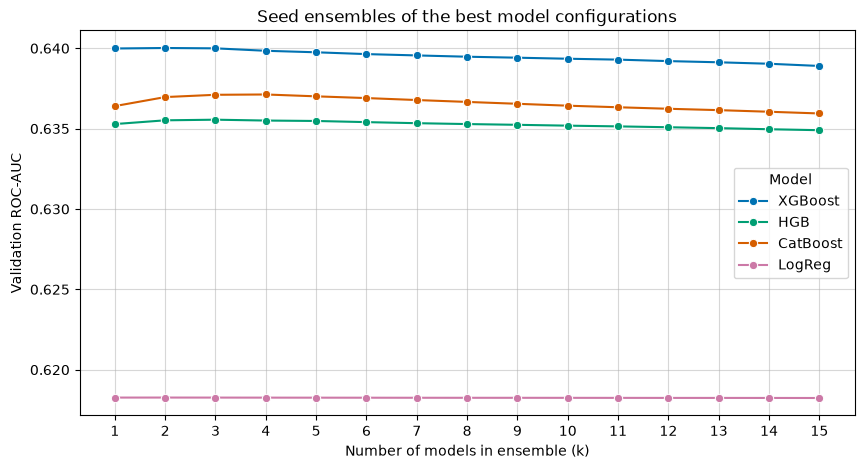

In [74]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_seed,
    x="k",
    y="auc_val",
    hue="model",
    marker="o",
    ax=ax
)

ax.set_xlabel("Number of models in ensemble (k)")
ax.set_ylabel("Validation ROC-AUC")

ax.set_title(
    "Seed ensembles of the best model configurations"
)

ax.set_xticks(range(1, 16))

ax.legend(
    title="Model"
)

ax.grid(alpha=0.5)

plt.show()

### Experiment 4: Stacking Ensembles Based on the Strongest Individual Models

Stacking is a classic ensemble strategy in which a meta learner is trained on the individual models predictions as new features to form a final prediction. The hope with stacking is that a model can dynamically learn which ensemble member to trust and when, rather than, for example, simply taking a rigid average over all predictions.

In [75]:
stacking_modelle = {
    "XGBoost": xgb_opt,
    "HGB": hgb_opt,
    "Cat1": cb_opt_1,
    "Cat2": cb_opt_2,
    "Cat3": cb_opt_3,
    "LogReg": lr_opt
}

In [76]:
stack_basen = {
    "XGBoost": clone(xgb_opt),
    "HGB": clone(hgb_opt),
    "LogReg": clone(lr_opt)
}

In [77]:
for name, model in {
    "Cat1": cb_opt_1,
    "Cat2": cb_opt_2,
    "Cat3": cb_opt_3
}.items():

    params = model["clf"].get_params()

    stack_basen[name] = Pipeline([
        ("prep", clone(model["prep"])),
        ("clf", CatBoostClassifier(**params))
    ])

In [78]:
stack_basen["XGBoost"].set_params(
    clf__n_estimators=xgb_opt["clf"].best_iteration + 1,
    clf__early_stopping_rounds=None
)

stack_basen["HGB"].set_params(
    clf__max_iter=hgb_opt["clf"].n_iter_,
    clf__early_stopping=False
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer-1', ...), ('columntransformer-2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters 

In [79]:
for name, original in {
    "Cat1": cb_opt_1,
    "Cat2": cb_opt_2,
    "Cat3": cb_opt_3
}.items():

    stack_basen[name].set_params(
        clf__iterations=original["clf"].get_best_iteration() + 1,
        clf__use_best_model=False,
        clf__early_stopping_rounds=None
    )

In [80]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_preds = pd.DataFrame(
    index=x_train.index,
    columns=stacking_modelle.keys(),
    dtype=float
)

In [81]:
for name, basis in stack_basen.items():

    print(name)

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(x_train, y_train)
    ):

        print("Fold", fold + 1)

        model = set_seed(
            basis,
            RANDOM_STATE
        )

        model.fit(
            x_train.iloc[train_idx],
            y_train.iloc[train_idx]
        )

        oof_preds.iloc[
            val_idx,
            oof_preds.columns.get_loc(name)
        ] = model.predict_proba(
            x_train.iloc[val_idx]
        )[:, 1]

XGBoost
Fold 1
Fold 2
Fold 3
HGB
Fold 1


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 2


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 3


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


LogReg
Fold 1


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

Fold 2


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

Fold 3


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

Cat1
Fold 1
Fold 2
Fold 3
Cat2
Fold 1
Fold 2
Fold 3
Cat3
Fold 1
Fold 2
Fold 3


In [82]:
stack_val = pd.DataFrame({
    "XGBoost": xgb_opt.predict_proba(x_val)[:, 1],
    "HGB": hgb_opt.predict_proba(x_val)[:, 1],
    "Cat1": cb_opt_1.predict_proba(x_val)[:, 1],
    "Cat2": cb_opt_2.predict_proba(x_val)[:, 1],
    "Cat3": cb_opt_3.predict_proba(x_val)[:, 1],
    "LogReg": lr_opt.predict_proba(x_val)[:, 1]
})

In [83]:
stack_test = pd.DataFrame({
    "XGBoost": xgb_opt.predict_proba(x_test)[:, 1],
    "HGB": hgb_opt.predict_proba(x_test)[:, 1],
    "Cat1": cb_opt_1.predict_proba(x_test)[:, 1],
    "Cat2": cb_opt_2.predict_proba(x_test)[:, 1],
    "Cat3": cb_opt_3.predict_proba(x_test)[:, 1],
    "LogReg": lr_opt.predict_proba(x_test)[:, 1]
})

In [84]:
oof_preds.isna().sum()

XGBoost    0
HGB        0
Cat1       0
Cat2       0
Cat3       0
LogReg     0
dtype: int64

In [85]:
stacking_results = []

for k in range(2, 7):

    for combo in combinations(
        oof_preds.columns,
        k
    ):

        combo = list(combo)

        meta = LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )

        meta.fit(
            oof_preds[combo],
            y_train
        )

        pred_val = meta.predict_proba(
            stack_val[combo]
        )[:, 1]

        pred_test = meta.predict_proba(
            stack_test[combo]
        )[:, 1]

        stacking_results.append({
            "k": k,
            "models": " + ".join(combo),
            "auc_val": roc_auc_score(
                y_val,
                pred_val
            ),
            "auc_test": roc_auc_score(
                y_test,
                pred_test
            )
        })

In [86]:
df_stacking = pd.DataFrame(
    stacking_results
)

best_stack_pro_k = (
    df_stacking
    .sort_values("auc_val", ascending=False)
    .groupby("k")
    .head(1)
    .sort_values("k")
)

best_stack_pro_k

,k,models,auc_val,auc_test
2,2,XGBoost + Cat2,0.639608,0.650003
22,3,XGBoost + Cat2 + Cat3,0.639161,0.650243
38,4,XGBoost + HGB + Cat2 + Cat3,0.638678,0.650273
50,5,XGBoost + HGB + Cat1 + Cat2 + Cat3,0.638196,0.650175
56,6,XGBoost + HGB + Cat1 + Cat2 + Cat3 + LogReg,0.623737,0.641422
